In [1]:
import os.path
import numpy as np
import pandas as pd
import re
from sklearn.model_selection import train_test_split
import os, time, json, math
from typing import List, Any, Tuple
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from fasterrisk.fasterrisk import RiskScoreOptimizer, RiskScoreClassifier
from helpers import *

在此文件中，我们将用NLST文件训练一个fasterrisk模型和pancan模型，然后将此fasterrisk用于DLCS的test set中

## Train model on NLST

In [2]:
# Data files
CSV1 = 'ml_dataset/nlst_ct_nodule_df_set1.csv'
CSV2 = 'ml_dataset/nlst_ct_nodule_df_set2.csv'

# -------------------------
# Load, normalize/encode
# -------------------------
df1 = pd.read_csv(CSV1)
df2 = pd.read_csv(CSV2)

df1 = filter_age_le_70(df1)
df2 = filter_age_le_70(df2)

df1 = normalize_and_encode(df1)
df2 = normalize_and_encode(df2)

df1['sct_ab_gwth'] = df1['sct_ab_gwth'].fillna(0)
df2['sct_ab_gwth'] = df2['sct_ab_gwth'].fillna(0)

df1 = df1.dropna(subset=['sct_perp_dia'])
df2 = df2.dropna(subset=['sct_perp_dia'])

### Train fasterrisk

In [3]:
LABEL_COL = 'Cancer_lbl'
ID_COL    = 'pid'

FEATURES_STLMD  = ['sct_long_dia','part_solid','ground_glass','solid','Upper_Lobe','Spiculation','age','sex', 'sct_found_after_comp', 'sct_perp_dia']

# ≥ cutpoints for binning (age & size)
CUTS_CONT = {
    "age": [55, 58, 61, 64, 67],
    "sct_long_dia": [6, 8, 10, 15, 20, 30],
    "sct_perp_dia": [5, 7, 10, 12, 15, 20],
}

# binary passthroughs (copied as-is)
BIN_PASSTHROUGH_STLMD  = ['part_solid','ground_glass','solid','Upper_Lobe','Spiculation','sex', 'sct_found_after_comp']

# ---- knobs you can tune ----
SPARSITY_K        = 5
PARENT_SIZE       = 50

# Rashomon / diversity knobs (documented in FasterRisk)
GAP_TOLERANCE     = 0.15   # larger -> accept more near-optimal models
SELECT_TOP_M      = 100    # keep more diverse supports
MAX_ATTEMPTS      = 200    # try more swaps/diversification

# choose which designs to run
DESIGNS_TO_RUN = ["STLMD"]

# ROC subplot grid (50 per page)
SUBPLOT_ROWS = 10
SUBPLOT_COLS = 5

In [4]:
# -------------------------
# Patient-level stratified split (on df1)
# -------------------------
patients = df1[[ID_COL, LABEL_COL]].drop_duplicates()
train_patients, val_patients = train_test_split(
    patients,
    test_size=0.2,
    stratify=patients[LABEL_COL],
    random_state=42
)
train_df = df1[df1[ID_COL].isin(train_patients[ID_COL])]
val_df   = df1[df1[ID_COL].isin(val_patients[ID_COL])]

X_train_STLMD_df, y_train_STLMD_raw = prepare_data(train_df, FEATURES_STLMD, LABEL_COL)
X_val_STLMD_df,   y_val_STLMD_raw   = prepare_data(val_df,   FEATURES_STLMD, LABEL_COL)
X_test_STLMD_df,  y_test_STLMD_raw  = prepare_data(df2,      FEATURES_STLMD, LABEL_COL)

X_train_STLMD_bin, X_val_STLMD_bin, X_test_STLMD_bin = binarize_and_align_custom(
    X_train_STLMD_df, X_val_STLMD_df, X_test_STLMD_df,
    feature_cuts={"age": CUTS_CONT["age"], "sct_long_dia": CUTS_CONT["sct_long_dia"], "sct_perp_dia": CUTS_CONT["sct_perp_dia"]},
    passthrough_binary=BIN_PASSTHROUGH_STLMD
)

y_train_STLMD = to_fastrisk_y(y_train_STLMD_raw, pos_label=1)
y_val_STLMD   = to_fastrisk_y(y_val_STLMD_raw,   pos_label=1)
y_test_STLMD  = to_fastrisk_y(y_test_STLMD_raw,  pos_label=1)

X_train_STLMD = X_train_STLMD_bin.to_numpy(dtype=float)
X_val_STLMD   = X_val_STLMD_bin.to_numpy(dtype=float)
X_test_STLMD  = X_test_STLMD_bin.to_numpy(dtype=float)

# 将标签转换为 {0, 1} 格式（RandomForest 需要）
y_train_STLMD_01 = (y_train_STLMD + 1.0) / 2.0
y_test_STLMD_01 = (y_test_STLMD + 1.0) / 2.0


# Optional: feature names for each design
FEATURE_NAMES_STLMD  = list(X_train_STLMD_bin.columns)

In [5]:
# ---------------------------------------------
# Wire up your prepared splits & feature names
# (These are defined in your dataset block.)
# ---------------------------------------------

SPLITS = {
    "STLMD": (X_train_STLMD, y_train_STLMD, X_val_STLMD, y_val_STLMD, X_test_STLMD, y_test_STLMD, FEATURE_NAMES_STLMD),
}

for name in DESIGNS_TO_RUN:
    print(f"\n=== Processing: {name} ===")
    (X_train, y_train, X_val, y_val, X_test, y_test, feature_names) = SPLITS[name]

    # build optimizer with Rashomon controls
    opt = make_optimizer(
        X=X_train, y=y_train,
        k=SPARSITY_K, parent_size=PARENT_SIZE,
        gap_tolerance=GAP_TOLERANCE,
        select_top_m=SELECT_TOP_M,
        max_attempts=MAX_ATTEMPTS,
        want_intercept=True
    )
    print(f"[opt] gap_tolerance={GAP_TOLERANCE}, select_top_m={SELECT_TOP_M}, maxAttempts={MAX_ATTEMPTS}, k={SPARSITY_K}, parent_size={PARENT_SIZE}")

    t0 = time.time()
    opt.optimize()
    print("Optimization takes {:.2f} seconds.".format(time.time() - t0))

    multipliers, beta0_int, betas_int = extract_models(opt.get_models())
    print("We generate {} risk score models from the sparse diverse pool".format(len(multipliers)))


=== Processing: STLMD ===
[opt] gap_tolerance=0.15, select_top_m=100, maxAttempts=200, k=5, parent_size=50
Optimization takes 95.63 seconds.
We generate 86 risk score models from the sparse diverse pool


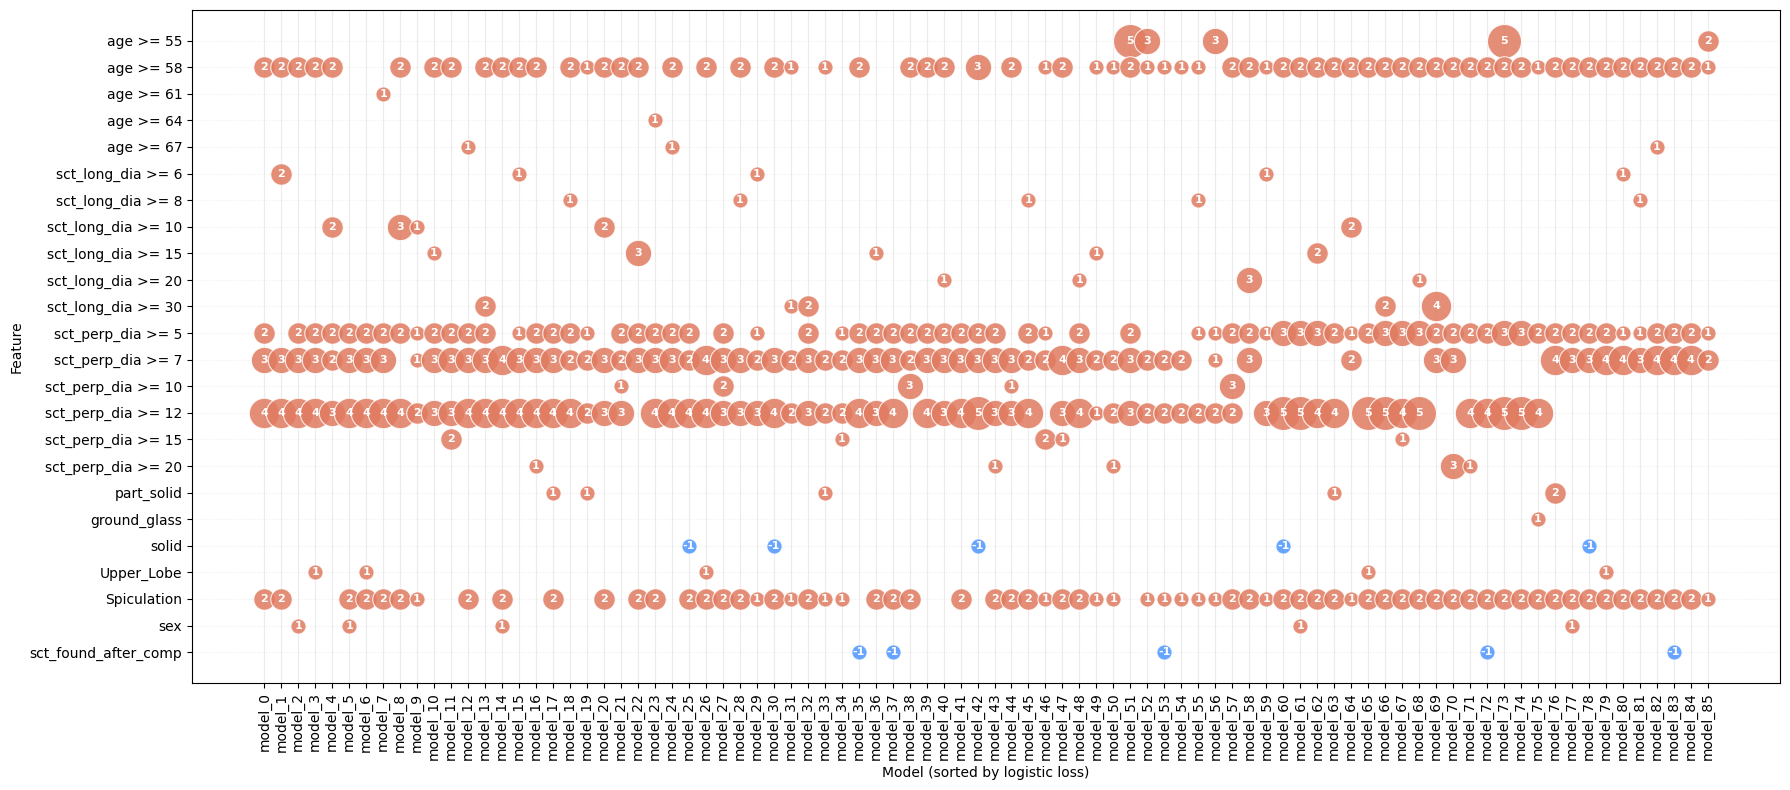

In [6]:
plot_feature_model_matrix(betas_int, X_train_STLMD_bin)

In [7]:
# 保存模型参数 + 特征语义信息（系数与特征名一一对应）
fasterrisk_model = {
    "multipliers": np.asarray(multipliers, dtype=float),
    "beta0_int": np.asarray(beta0_int, dtype=int),
    "betas_int": np.asarray(betas_int, dtype=int),
    "feature_names": list(X_train_STLMD_bin.columns),
    "feature_cuts": {
        "age": CUTS_CONT["age"],
        "sct_long_dia": CUTS_CONT["sct_long_dia"],
        "sct_perp_dia": CUTS_CONT["sct_perp_dia"],
    },
    "passthrough_binary": list(BIN_PASSTHROUGH_STLMD),
    "raw_features": list(FEATURES_STLMD),
    "label_col": LABEL_COL,
}

In [8]:
def predict_prob_fasterrisk(row_or_df, model, model_idx=None):
    """
    row_or_df: df1 的单行 (Series) 或单行 DataFrame
    model_idx:
        - None: 使用所有子模型做平均（原先 ensemble 逻辑）
        - int: 使用指定子模型（0-based index）
    返回: 癌症预测概率(float)
    """
    if isinstance(row_or_df, pd.Series):
        X_raw = row_or_df.to_frame().T
    else:
        X_raw = row_or_df.copy()

    # 如果传入的是未编码原始行，先做类别规范化编码
    need_encode = any(col not in X_raw.columns for col in model["passthrough_binary"])
    if need_encode and {"gender", "Nodule_Type"}.issubset(set(X_raw.columns)):
        X_raw = normalize_and_encode(X_raw)

    X_raw = X_raw[model["raw_features"]]

    X_bin = build_binary_matrix(
        X_raw,
        feature_cuts=model["feature_cuts"],
        passthrough_binary=model["passthrough_binary"],
    ).reindex(columns=model["feature_names"], fill_value=0)

    X_np = X_bin.to_numpy(dtype=float)

    n_models = len(model["multipliers"])
    if model_idx is None:
        selected_indices = range(n_models)
    else:
        model_idx = int(model_idx)
        if model_idx < 0 or model_idx >= n_models:
            raise IndexError(f"model_idx must be in [0, {n_models - 1}], got {model_idx}")
        selected_indices = [model_idx]

    probs = []
    for i in selected_indices:
        m = model["multipliers"][i]
        b0 = model["beta0_int"][i]
        w = model["betas_int"][i]
        p = model_probs(float(m), float(b0), np.asarray(w, dtype=int), X_np)[0]
        probs.append(float(p))

    prob_cancer = float(np.mean(probs))
    return prob_cancer


# 示例：从 df1 取一行并输出指定子模型的 predicted probability
example_idx = 0
model_idx = 0
prob_cancer = predict_prob_fasterrisk(df1.iloc[example_idx], fasterrisk_model, model_idx=model_idx)
print(f"predicted probability of Cancer_lbl=1 (model_{model_idx}):", round(prob_cancer, 4))

predicted probability of Cancer_lbl=1 (model_0): 0.0327


### Train PanCan

In [9]:
df1_pancan = train_df.copy()
df1_pancan['gender'] = df1_pancan['gender'].map({'male': 0, 'female': 1}).astype(int)

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

pancan_features = [
    'age', 'gender', 'Family_History', 'diagemph', 'sct_long_dia',
    'ground_glass', 'part_solid', 'Upper_Lobe', 'Spiculation', 'num_nodule'
]

model_df = df1_pancan[pancan_features + [LABEL_COL]].apply(pd.to_numeric, errors='coerce').dropna()
X_pancan = model_df[pancan_features]
y_pancan = model_df[LABEL_COL].astype(int)

pancan_lr = LogisticRegression(penalty=None, solver='lbfgs', max_iter=5000, random_state=42)
pancan_lr.fit(X_pancan, y_pancan)

pancan_coef = dict(zip(pancan_features, pancan_lr.coef_[0].astype(float)))
pancan_coef['intercept'] = float(pancan_lr.intercept_[0])

train_pred_probs_pancan = pd.Series(pancan_lr.predict_proba(X_pancan)[:, 1], index=model_df.index)
train_auc_pancan = roc_auc_score(y_pancan, train_pred_probs_pancan)


def pancan_predict_proba(df: pd.DataFrame) -> pd.Series:
    X = df[pancan_features].apply(pd.to_numeric, errors='coerce')
    probs = pd.Series(np.nan, index=df.index, dtype=float)
    valid_mask = X.notna().all(axis=1)
    probs.loc[valid_mask] = pancan_lr.predict_proba(X.loc[valid_mask])[:, 1]
    return probs


print(f"Train AUC: {train_auc_pancan:.4f}")
print({k: round(v, 6) for k, v in pancan_coef.items()})

Train AUC: 0.7246
{'age': 0.039137, 'gender': 0.30223, 'Family_History': -0.086076, 'diagemph': 0.347858, 'sct_long_dia': 0.091894, 'ground_glass': 0.357964, 'part_solid': 0.551877, 'Upper_Lobe': 0.189953, 'Spiculation': 0.758974, 'num_nodule': -0.004613, 'intercept': -6.729704}


## Comparison on DLCS

### fasterrisk on DLCS

In [11]:
DLCS_CSV1 = 'DLCS_dataset/DLCSD24_Annotations (1).csv'
DLCS_CSV2 = 'DLCS_dataset/DLCSD24_metadata_v1.1 (1).csv'

dlcs_annotations = pd.read_csv(DLCS_CSV1)
dlcs_metadata = pd.read_csv(DLCS_CSV2)

dlcs_data = dlcs_annotations.merge(dlcs_metadata, on='patient-id', how='left')
dlcs_train = dlcs_data.loc[dlcs_data['benchmark_split'] == 'train'].copy()
dlcs_train = dlcs_train.rename(columns={
    'w': 'sct_long_dia',
    'h': 'sct_perp_dia',
    'Sex': 'sex',
    'Age': 'age',
})

In [12]:
def predict_prob_fasterrisk_rows(
    df: pd.DataFrame,
    model: dict,
    model_idx: int = 0,
    missing_fill: float = 0.0,
    verbose: bool = True,
) -> pd.Series:
    X_raw = df.copy()

    # If raw categorical columns exist, try to derive binary features first.
    missing_raw = [c for c in model["raw_features"] if c not in X_raw.columns]
    if missing_raw and {"gender", "Nodule_Type"}.issubset(X_raw.columns):
        X_raw = normalize_and_encode(X_raw)
        missing_raw = [c for c in model["raw_features"] if c not in X_raw.columns]

    if missing_raw:
        for c in missing_raw:
            X_raw[c] = missing_fill
        if verbose:
            print(f"[warn] Missing raw features filled with {missing_fill}: {missing_raw}")

    X_raw = X_raw.reindex(columns=model["raw_features"])
    X_raw = X_raw.apply(pd.to_numeric, errors="coerce").fillna(missing_fill)

    X_bin = build_binary_matrix(
        X_raw,
        feature_cuts=model["feature_cuts"],
        passthrough_binary=model["passthrough_binary"],
    ).reindex(columns=model["feature_names"], fill_value=0)

    n_models = len(model["multipliers"])
    model_idx = int(model_idx)
    if model_idx < 0 or model_idx >= n_models:
        raise IndexError(f"model_idx must be in [0, {n_models - 1}], got {model_idx}")

    m = float(model["multipliers"][model_idx])
    b0 = float(model["beta0_int"][model_idx])
    w = np.asarray(model["betas_int"][model_idx], dtype=int)

    probs = model_probs(m, b0, w, X_bin.to_numpy(dtype=float))
    return pd.Series(probs, index=df.index, name=f"pred_prob_fasterrisk_model_{model_idx}")

In [ ]:
# Pseudo 5-fold CV on dlcs_train to regenerate pred_prob_fasterrisk
# Reuse predict_prob_fasterrisk_rows from Cell 17 for cleaner code.

label_col = "Malignant_lbl"

# Parse label to binary {0,1}
y_raw = pd.to_numeric(dlcs_train[label_col], errors="coerce").to_numpy(dtype=float)
valid_y_mask = np.isfinite(y_raw)
if valid_y_mask.sum() == 0:
    raise ValueError(f"{label_col} has no valid numeric labels")

uniq = np.unique(y_raw[valid_y_mask])
uniq_set = set(uniq.tolist())
if uniq_set.issubset({0.0, 1.0}):
    y_bin = y_raw.copy()
elif uniq_set.issubset({-1.0, 1.0}):
    y_bin = (y_raw + 1.0) / 2.0
elif len(uniq) == 2:
    low, high = float(np.min(uniq)), float(np.max(uniq))
    y_bin = np.full_like(y_raw, np.nan, dtype=float)
    y_bin[y_raw == low] = 0.0
    y_bin[y_raw == high] = 1.0
else:
    raise ValueError(f"{label_col} is not binary-like, unique values: {uniq.tolist()}")

valid_y_mask = np.isfinite(y_bin)

# 5-fold split (original random split)
n_splits = 5
rng = np.random.default_rng(42)
N = len(dlcs_train)
all_pos = np.arange(N)
folds = np.array_split(rng.permutation(all_pos), n_splits)

fold_pos_counts = []
for f in folds:
    f_valid = f[valid_y_mask[f]]
    fold_pos_counts.append(int(np.sum(y_bin[f_valid] == 1)))
print(f"[info] Malignant_lbl=1 count per fold: {fold_pos_counts}")

pred_oof = np.full(N, np.nan, dtype=float)
selected_models = []
fold_rows = []
n_models = len(fasterrisk_model["multipliers"])

for fold_id, test_pos in enumerate(folds, start=1):
    train_pos = np.setdiff1d(all_pos, test_pos, assume_unique=True)
    train_eval_pos = train_pos[valid_y_mask[train_pos]]

    if len(train_eval_pos) == 0:
        best_idx, best_score = 0, np.nan
    else:
        train_eval_df = dlcs_train.iloc[train_eval_pos]
        y_train = y_bin[train_eval_pos].astype(int)

        best_idx, best_score = 0, -np.inf
        for midx in range(n_models):
            p_train = predict_prob_fasterrisk_rows(
                train_eval_df,
                fasterrisk_model,
                model_idx=midx,
                missing_fill=0.0,
                verbose=False,
            ).to_numpy(dtype=float)

            if np.unique(y_train).size >= 2:
                score = float(roc_auc_score(y_train, p_train))
            else:
                score = float(((p_train >= 0.5).astype(int) == y_train).mean())

            if score > best_score:
                best_idx, best_score = midx, score

    test_df = dlcs_train.iloc[test_pos]
    pred_oof[test_pos] = predict_prob_fasterrisk_rows(
        test_df,
        fasterrisk_model,
        model_idx=best_idx,
        missing_fill=0.0,
        verbose=False,
    ).to_numpy(dtype=float)

    selected_models.append(int(best_idx))
    fold_rows.append({
        "fold": fold_id,
        "best_model_idx": int(best_idx),
        "train_score": float(best_score) if np.isfinite(best_score) else np.nan,
        "n_train_eval": int(len(train_eval_pos)),
        "n_holdout": int(len(test_pos)),
    })

dlcs_train["pred_prob_fasterrisk"] = pred_oof



[info] Malignant_lbl=1 count per fold: [44, 30, 21, 30, 41]


Plotting model indices: [44, 30, 21, 30, 41]


C:\Users\YiJin\AppData\Local\Temp\ipykernel_26720\1780221797.py:26: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


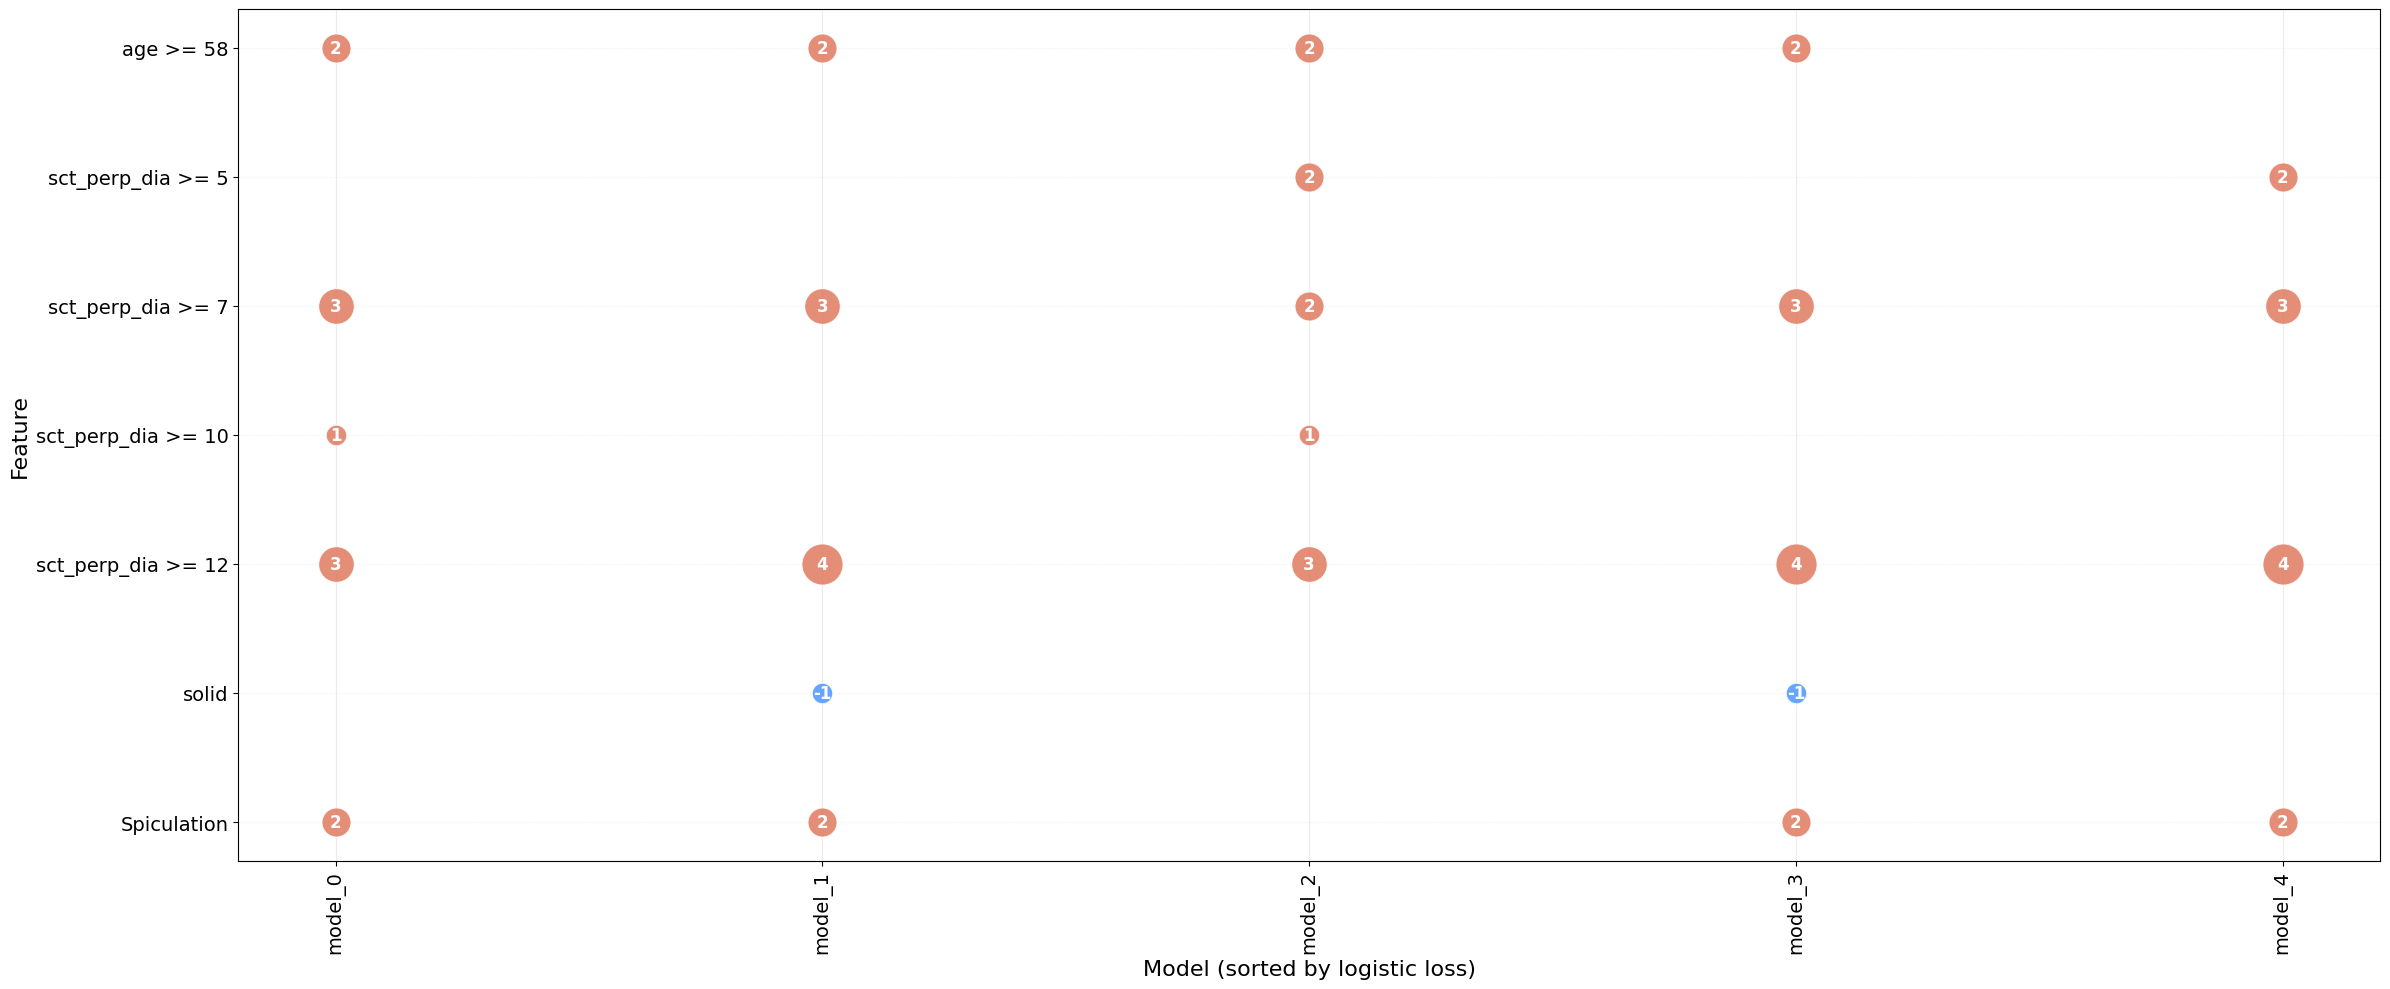

In [23]:
# Visualize the 5 specified FasterRisk sub-models.
models_to_plot = [44, 30, 21, 30, 41]
betas_all = np.asarray(fasterrisk_model["betas_int"])
invalid_idx = [i for i in models_to_plot if i < 0 or i >= betas_all.shape[0]]
if invalid_idx:
    raise IndexError(f"Invalid model index/indices: {invalid_idx}; valid range is [0, {betas_all.shape[0] - 1}]")

betas_selected = betas_all[models_to_plot, :]
print(f"Plotting model indices: {models_to_plot}")
plot_feature_model_matrix(
    betas_selected,
    X_train_STLMD_bin,
    figsize=(24, 10),
    base_size=220,
)

ax = plt.gca()
ax.set_xlabel("Model (sorted by logistic loss)", fontsize=16)
ax.set_ylabel("Feature", fontsize=16)
ax.tick_params(axis="x", labelsize=14)
ax.tick_params(axis="y", labelsize=14)

for text in ax.texts:
    text.set_fontsize(12)

plt.tight_layout()
plt.show()

### pancan on DLCS

In [14]:
dlcs_train["num_nodule"] = dlcs_train.groupby("patient-id")["patient-id"].transform("size")

pancan_intercept = float(pancan_coef.get("intercept", 0.0))
pancan_feature_coefs = {k: float(v) for k, v in pancan_coef.items() if k != "intercept"}

available_features = [f for f in pancan_feature_coefs if f in dlcs_train.columns]
missing_features = [f for f in pancan_feature_coefs if f not in dlcs_train.columns]

linear_term = np.full(len(dlcs_train), pancan_intercept, dtype=float)
for feat in available_features:
    x = pd.to_numeric(dlcs_train[feat], errors="coerce").fillna(0.0).to_numpy(dtype=float)
    linear_term += pancan_feature_coefs[feat] * x

# Missing features are ignored (zero contribution).
linear_term = np.clip(linear_term, -50.0, 50.0)
dlcs_train["pred_prob_pancan"] = 1.0 / (1.0 + np.exp(-linear_term))

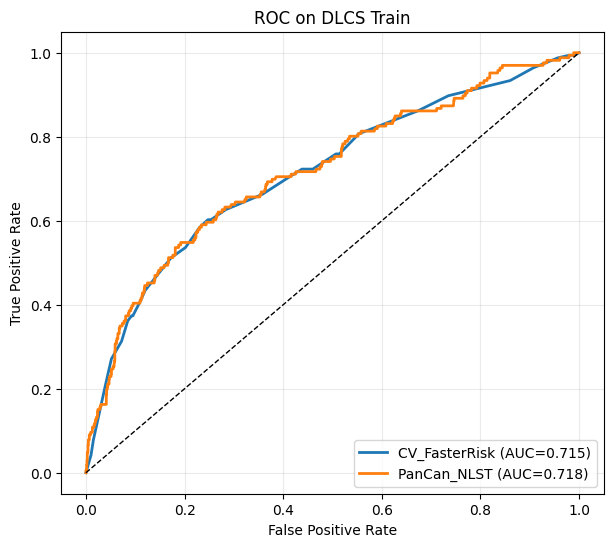

In [30]:
label_col = "Malignant_lbl"

y_true = pd.to_numeric(dlcs_train[label_col], errors="coerce")
p_faster = pd.to_numeric(dlcs_train["pred_prob_fasterrisk"], errors="coerce")
p_pancan = pd.to_numeric(dlcs_train["pred_prob_pancan"], errors="coerce")

mask_faster = y_true.notna() & p_faster.notna()
mask_pancan = y_true.notna() & p_pancan.notna()

if mask_faster.sum() == 0 or mask_pancan.sum() == 0:
    raise ValueError("No valid rows for ROC. Please check labels/predictions.")

fpr_faster, tpr_faster, _ = roc_curve(y_true[mask_faster].astype(int), p_faster[mask_faster].astype(float))
fpr_pancan, tpr_pancan, _ = roc_curve(y_true[mask_pancan].astype(int), p_pancan[mask_pancan].astype(float))

auc_faster = auc(fpr_faster, tpr_faster)
auc_pancan = auc(fpr_pancan, tpr_pancan)

plt.figure(figsize=(7, 6))
plt.plot(fpr_faster, tpr_faster, lw=2, label=f"CV_FasterRisk (AUC={auc_faster:.3f})")
plt.plot(fpr_pancan, tpr_pancan, lw=2, label=f"PanCan_NLST (AUC={auc_pancan:.3f})")
plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC on DLCS Train")
plt.legend(loc="lower right")
plt.grid(alpha=0.25)
plt.show()

In [16]:
n_models = len(fasterrisk_model["multipliers"])
if n_models == 0:
    raise ValueError("No models found in fasterrisk_model")

pred_list = []
for midx in range(n_models):
    p_i = predict_prob_fasterrisk_rows(
        dlcs_train,
        fasterrisk_model,
        model_idx=midx,
        missing_fill=0.0,
        verbose=False,
    ).to_numpy(dtype=float)
    pred_list.append(p_i)

dlcs_train["predict_prob_ensemble"] = np.mean(np.vstack(pred_list), axis=0)

display(dlcs_train[["patient-id", "predict_prob_ensemble"]].head())

,patient-id,predict_prob_ensemble
0,DLCS_0001,0.020492
1,DLCS_0001,0.036756
2,DLCS_0002,0.020492
3,DLCS_0003,0.012370
4,DLCS_0004,0.036756


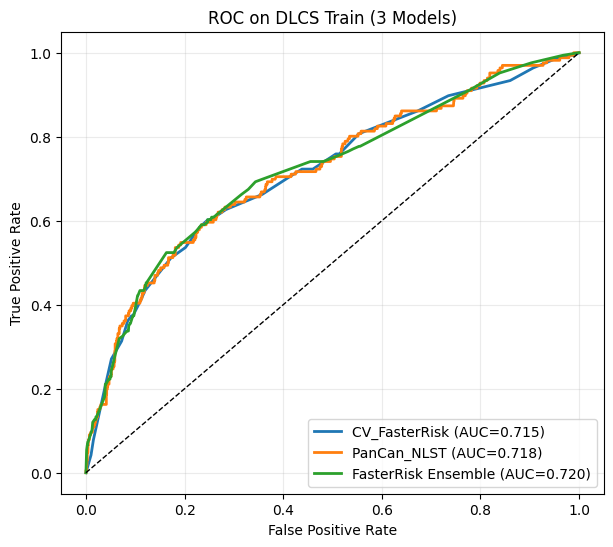

FasterRisk AUC: 0.7146
PanCan AUC: 0.7183
FasterRisk Ensemble AUC: 0.7196


In [29]:
label_col = "Malignant_lbl"

y_true = pd.to_numeric(dlcs_train[label_col], errors="coerce")
p_faster = pd.to_numeric(dlcs_train["pred_prob_fasterrisk"], errors="coerce")
p_pancan = pd.to_numeric(dlcs_train["pred_prob_pancan"], errors="coerce")
p_ensemble = pd.to_numeric(dlcs_train["predict_prob_ensemble"], errors="coerce")

mask_faster = y_true.notna() & p_faster.notna()
mask_pancan = y_true.notna() & p_pancan.notna()
mask_ensemble = y_true.notna() & p_ensemble.notna()

if mask_faster.sum() == 0 or mask_pancan.sum() == 0 or mask_ensemble.sum() == 0:
    raise ValueError("No valid rows for ROC. Please check labels/predictions.")

fpr_faster, tpr_faster, _ = roc_curve(y_true[mask_faster].astype(int), p_faster[mask_faster].astype(float))
fpr_pancan, tpr_pancan, _ = roc_curve(y_true[mask_pancan].astype(int), p_pancan[mask_pancan].astype(float))
fpr_ensemble, tpr_ensemble, _ = roc_curve(y_true[mask_ensemble].astype(int), p_ensemble[mask_ensemble].astype(float))

auc_faster = auc(fpr_faster, tpr_faster)
auc_pancan = auc(fpr_pancan, tpr_pancan)
auc_ensemble = auc(fpr_ensemble, tpr_ensemble)

plt.figure(figsize=(7, 6))
plt.plot(fpr_faster, tpr_faster, lw=2, label=f"CV_FasterRisk (AUC={auc_faster:.3f})")
plt.plot(fpr_pancan, tpr_pancan, lw=2, label=f"PanCan_NLST (AUC={auc_pancan:.3f})")
plt.plot(fpr_ensemble, tpr_ensemble, lw=2, label=f"FasterRisk Ensemble (AUC={auc_ensemble:.3f})")
plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC on DLCS Train (3 Models)")
plt.legend(loc="lower right")
plt.grid(alpha=0.25)
plt.show()

print(f"FasterRisk AUC: {auc_faster:.4f}")
print(f"PanCan AUC: {auc_pancan:.4f}")
print(f"FasterRisk Ensemble AUC: {auc_ensemble:.4f}")

       model_idx        auc
count  86.000000  86.000000
mean   42.500000   0.697005
std    24.969982   0.008704
min     0.000000   0.681820
25%    21.250000   0.690487
50%    42.500000   0.700032
75%    63.750000   0.702535
max    85.000000   0.711654

Best model: idx=1, AUC=0.7117
Worst model: idx=63, AUC=0.6818


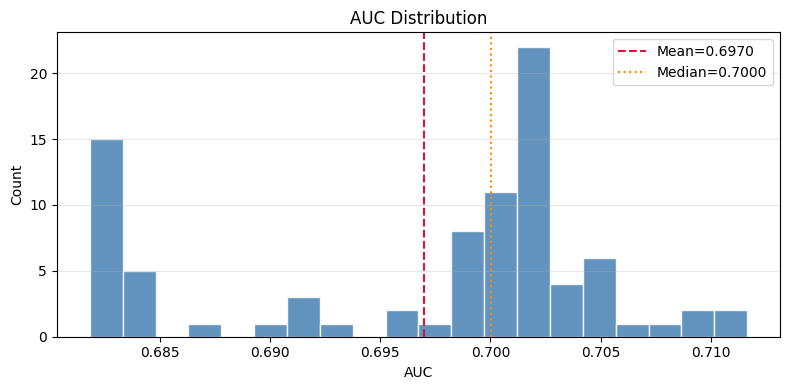

In [18]:

label_col = "Malignant_lbl"
y_true = pd.to_numeric(dlcs_train[label_col], errors="coerce")
mask = y_true.notna()

n_models = len(fasterrisk_model["multipliers"])
records = []
for midx in range(n_models):
    p_i = predict_prob_fasterrisk_rows(
        dlcs_train, fasterrisk_model, model_idx=midx, missing_fill=0.0, verbose=False
    )
    p_i = pd.to_numeric(p_i, errors="coerce")
    valid = mask & p_i.notna()
    fpr_i, tpr_i, _ = roc_curve(y_true[valid].astype(int), p_i[valid].astype(float))
    auc_i = auc(fpr_i, tpr_i)
    records.append({"model_idx": midx, "auc": auc_i})

model_auc_df = pd.DataFrame(records)
print(model_auc_df.describe())
print(f"\nBest model: idx={model_auc_df.loc[model_auc_df['auc'].idxmax(), 'model_idx']}, AUC={model_auc_df['auc'].max():.4f}")
print(f"Worst model: idx={model_auc_df.loc[model_auc_df['auc'].idxmin(), 'model_idx']}, AUC={model_auc_df['auc'].min():.4f}")

plt.figure(figsize=(8, 4))
plt.hist(model_auc_df["auc"], bins=20, edgecolor="white", color="steelblue", alpha=0.85)
plt.axvline(model_auc_df["auc"].mean(), color="crimson", linestyle="--", lw=1.5, label=f"Mean={model_auc_df['auc'].mean():.4f}")
plt.axvline(model_auc_df["auc"].median(), color="darkorange", linestyle=":", lw=1.5, label=f"Median={model_auc_df['auc'].median():.4f}")
plt.xlabel("AUC")
plt.ylabel("Count")
plt.title("AUC Distribution")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


In [19]:
n_models = len(fasterrisk_model["multipliers"])
X_test_np = np.asarray(X_test_STLMD, dtype=float)
y_test_bin = np.asarray(y_test_STLMD_01, dtype=float).reshape(-1)

if X_test_np.shape[0] != y_test_bin.shape[0]:
    raise ValueError(f"X_test_STLMD rows ({X_test_np.shape[0]}) != y_test_STLMD_01 length ({y_test_bin.shape[0]})")

auc_test_map = {}
for midx in range(n_models):
    m = float(fasterrisk_model["multipliers"][midx])
    b0 = float(fasterrisk_model["beta0_int"][midx])
    w = np.asarray(fasterrisk_model["betas_int"][midx], dtype=int)

    p_test = np.asarray(model_probs(m, b0, w, X_test_np), dtype=float).reshape(-1)
    valid = np.isfinite(y_test_bin) & np.isfinite(p_test)
    if valid.sum() == 0:
        auc_test_map[midx] = np.nan
        continue

    fpr_i, tpr_i, _ = roc_curve(y_test_bin[valid].astype(int), p_test[valid])
    auc_test_map[midx] = auc(fpr_i, tpr_i)

model_auc_df["auc_nlst_test"] = model_auc_df["model_idx"].map(auc_test_map)

display(model_auc_df.head())
print(model_auc_df[["auc", "auc_nlst_test"]].describe())


,model_idx,auc,auc_nlst_test
0,0,0.702517,0.706770
1,1,0.711654,0.716719
2,2,0.702517,0.699048
3,3,0.702517,0.711084
4,4,0.704792,0.706680


             auc  auc_nlst_test
count  86.000000      86.000000
mean    0.697005       0.701720
std     0.008704       0.010362
min     0.681820       0.670206
25%     0.690487       0.698312
50%     0.700032       0.703198
75%     0.702535       0.706633
max     0.711654       0.723354


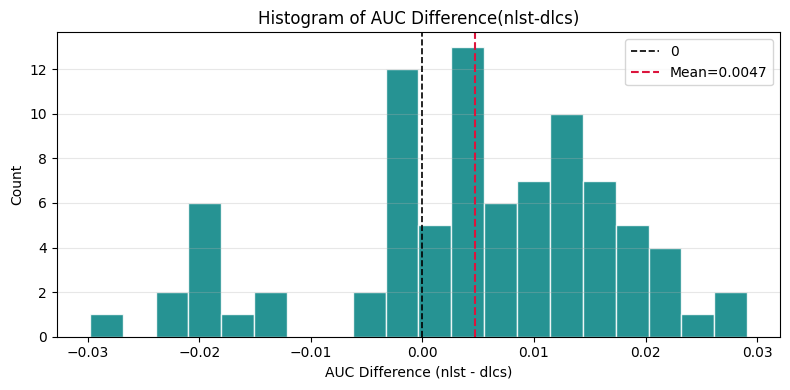

count    86.000000
mean      0.004715
std       0.012709
min      -0.029819
25%      -0.001499
50%       0.005253
75%       0.013772
max       0.029107
Name: auc_diff_test_minus_train, dtype: float64


In [21]:
required_cols = ["auc_nlst_test", "auc"]
missing_cols = [c for c in required_cols if c not in model_auc_df.columns]
if missing_cols:
    raise ValueError(f"model_auc_df is missing required columns: {missing_cols}")

model_auc_df["auc_diff_test_minus_train"] = model_auc_df["auc_nlst_test"] - model_auc_df["auc"]
diff = pd.to_numeric(model_auc_df["auc_diff_test_minus_train"], errors="coerce").dropna()

if diff.empty:
    raise ValueError("No valid values in auc_nlst_test - auc for plotting.")

plt.figure(figsize=(8, 4))
plt.hist(diff, bins=20, edgecolor="white", color="teal", alpha=0.85)
plt.axvline(0.0, color="black", linestyle="--", lw=1.2, label="0")
plt.axvline(diff.mean(), color="crimson", linestyle="--", lw=1.5, label=f"Mean={diff.mean():.4f}")
plt.xlabel("AUC Difference (nlst - dlcs)")
plt.ylabel("Count")
plt.title("Histogram of AUC Difference(nlst-dlcs)")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print(diff.describe())

In [ ]:
dlcs_available_features = {"sct_long_dia", "sct_perp_dia", "age", "sex"}
raw_features = list(fasterrisk_model["raw_features"])
raw_feature_set = set(raw_features)
feature_names = list(fasterrisk_model["feature_names"])
betas_all = np.asarray(fasterrisk_model["betas_int"])


def infer_raw_feature(feature_name: str) -> str:
    name = str(feature_name).strip()
    if name in raw_feature_set:
        return name

    for op in [">=", "<=", ">", "<", "=="]:
        if op in name:
            left = name.split(op, 1)[0].strip()
            if left in raw_feature_set:
                return left

    for raw in sorted(raw_features, key=len, reverse=True):
        if name.startswith(raw + "_") or name.startswith(raw + "[") or name.startswith(raw + "(") or name.startswith(raw + " "):
            return raw

    for raw in sorted(raw_features, key=len, reverse=True):
        if raw in name:
            return raw

    return name


missing_count_map = {}
missing_feature_list_map = {}
for midx in range(betas_all.shape[0]):
    used_idx = np.flatnonzero(betas_all[midx])
    used_raw_features = {infer_raw_feature(feature_names[j]) for j in used_idx}
    missing_used_features = sorted([f for f in used_raw_features if f not in dlcs_available_features])

    missing_count_map[midx] = len(missing_used_features)
    missing_feature_list_map[midx] = missing_used_features

model_auc_df["n_missing_features"] = model_auc_df["model_idx"].map(missing_count_map).astype("Int64")
model_auc_df["n_missing_features_in_dlcs"] = model_auc_df["n_missing_features"]
model_auc_df["missing_features_in_dlcs"] = model_auc_df["model_idx"].map(missing_feature_list_map)

display(model_auc_df[["model_idx", "auc", "auc_nlst_test", "n_missing_features", "missing_features_in_dlcs"]].head(10))

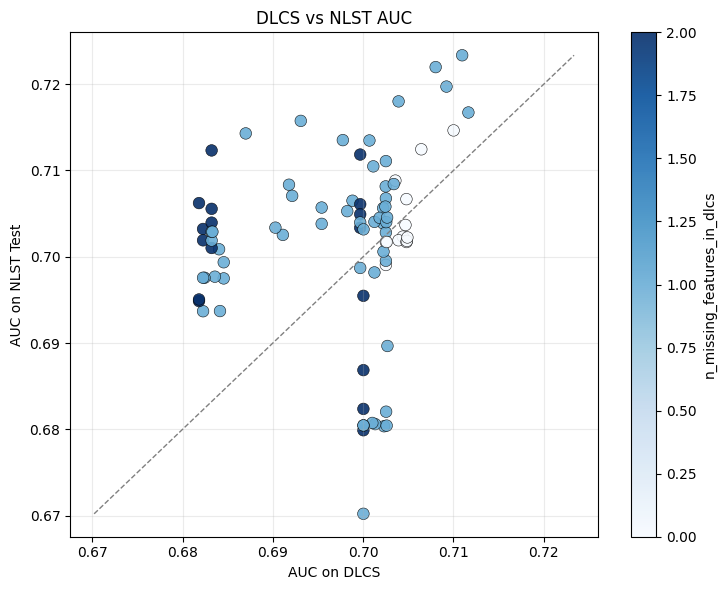

In [28]:
required_cols = ["auc", "auc_nlst_test", "n_missing_features_in_dlcs"]
missing_cols = [c for c in required_cols if c not in model_auc_df.columns]
if missing_cols:
    raise ValueError(f"model_auc_df is missing required columns: {missing_cols}")

plot_df = model_auc_df[required_cols].copy()
plot_df["auc"] = pd.to_numeric(plot_df["auc"], errors="coerce")
plot_df["auc_nlst_test"] = pd.to_numeric(plot_df["auc_nlst_test"], errors="coerce")
plot_df["n_missing_features_in_dlcs"] = pd.to_numeric(plot_df["n_missing_features_in_dlcs"], errors="coerce")
plot_df = plot_df.dropna()

if plot_df.empty:
    raise ValueError("No valid rows available for scatterplot.")

plt.figure(figsize=(7.5, 6))
scatter = plt.scatter(
    plot_df["auc"],
    plot_df["auc_nlst_test"],
    c=plot_df["n_missing_features_in_dlcs"],
    cmap="Blues",
    s=70,
    alpha=0.9,
    edgecolors="black",
    linewidths=0.4,
)

xy_min = float(min(plot_df["auc"].min(), plot_df["auc_nlst_test"].min()))
xy_max = float(max(plot_df["auc"].max(), plot_df["auc_nlst_test"].max()))
plt.plot([xy_min, xy_max], [xy_min, xy_max], linestyle="--", color="gray", linewidth=1)

cbar = plt.colorbar(scatter)
cbar.set_label("n_missing_features_in_dlcs")
plt.xlabel("AUC on DLCS")
plt.ylabel("AUC on NLST Test")
plt.title("DLCS vs NLST AUC")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()